In [1]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import vector
import matplotlib.pyplot as plt
import os
import sys
import json
from tqdm.auto import tqdm
vector.register_awkward() 

from typing import List, Dict, Any

# if not hasattr(sys.modules['__main__'], '__file__'):
#     from IPython.core.interactiveshell import InteractiveShell
#     InteractiveShell.ast_node_interactivity = "all"


In [2]:
def path_up(levels=0):
    """
    Return the directory of the current file (script) or CWD (notebook),
    moved 'levels' directories upward.
    
    Parameters
        levels : int, optional
            How many parent-directory steps to go up. 0 means "stay at base path".
    Returns
        str
            Absolute path after walking `levels` parents up from the base path.
    """
    if hasattr(sys.modules['__main__'], '__file__'):
        base = os.path.dirname(os.path.abspath(sys.modules['__main__'].__file__))
    else:
        base = os.getcwd()
    for _ in range(levels):
        base = os.path.abspath(os.path.join(base, ".."))

    return base


def get_nanoaod_data(year: int) -> Dict[str, Any]:
    """
    Load index JSON for a given YEAR from the project root/data directory.

    Returns:
        Parsed JSON object (dict or list depending on file contents).
    """
    # Base directories
    main_dir = path_up(3)
    data_dir = os.path.join(main_dir, "data")
    assert os.path.exists(data_dir), f"Data directory does not exist: {data_dir}"
    json_file = os.path.join(data_dir, f"index_{year}.json")

    # Load JSON
    with open(json_file, "r") as f:
        data = json.load(f)

    return data


def list_nanoaod_categories(year: int, verbose: bool = False) -> List[str]:
    """
    List top-level NanoAOD categories for a given year
    (e.g. 'HHbbtt', 'HH4b', 'Tau', 'EGamma', 'JetMET').
    """
    data = get_nanoaod_data(year)
    categories = sorted(data.keys())
    if verbose:
        print(f"[{year}] Available categories:")
        for cat in categories:
            print("  -", cat)
    return categories

def list_nanoaod_samples(year: int, category: str, verbose: bool = False) -> List[str]:
    """
    List samples in a given NanoAOD category.
    """
    data = get_nanoaod_data(year)
    if category not in data:
        raise ValueError(
            f"Category '{category}' not found for {year}. "
            f"Available: {', '.join(sorted(data.keys()))}"
        )

    samples = sorted(data[category].keys())
    if verbose:
        print(f"[{year}] Samples in category '{category}':")
        for s in samples:
            print("  -", s)
    return samples

def list_nanoaod_files(
    year: int, category: str, sample: str, verbose: bool = False
) -> List[str]:
    """
    List NanoAOD file paths for a specific (year, category, sample).
    """
    data = get_nanoaod_data(year)

    if category not in data:
        raise ValueError(
            f"Category '{category}' not found for {year}. "
            f"Available: {', '.join(sorted(data.keys()))}"
        )

    cat_dict = data[category]
    if sample not in cat_dict:
        raise ValueError(
            f"Sample '{sample}' not found in category '{category}' for {year}. "
            f"Available: {', '.join(sorted(cat_dict.keys()))}"
        )

    files = cat_dict[sample]
    if verbose:
        print(f"[{year}] Category '{category}', sample '{sample}':")
        print(f"  Number of files: {len(files)}")
    return files


def get_nanoaod_file(
    year: int, category: str, sample: str, file_index: int, verbose: bool = False
) -> str:
    """
    Get a single NanoAOD file path by index for (year, category, sample).
    """
    files = list_nanoaod_files(year, category, sample, verbose=False)

    if not (0 <= file_index < len(files)):
        raise IndexError(
            f"file_index {file_index} out of range [0, {len(files)-1}] "
            f"for sample '{sample}' in '{category}' ({year})."
        )

    file_path = files[file_index]
    if verbose:
        print(f"[{year}] {category}/{sample}, file_index={file_index}:")
        print(" ", file_path)

    return file_path

In [3]:
YEAR = 2022

In [4]:
cats = list_nanoaod_categories(
    year=YEAR, 
    # verbose=True
)
samples = list_nanoaod_samples(
    year = YEAR, 
    category = "HHbbtt", 
    # verbose=True
)

 
files = list_nanoaod_files(
    year = YEAR, 
    category = "HHbbtt", 
    sample = "GluGlutoHHto2B2Tau_kl-0p00_kt-1p00_c2-0p00",
    verbose=True
    )



[2022] Category 'HHbbtt', sample 'GluGlutoHHto2B2Tau_kl-0p00_kt-1p00_c2-0p00':
  Number of files: 34


In [5]:
file_indices = range(0, 3)  # First 3 files

file_paths = [
    get_nanoaod_file(
        year=YEAR,
        category="HHbbtt",
        sample="GluGlutoHHto2B2Tau_kl-0p00_kt-1p00_c2-0p00",
        file_index=i,
        verbose=False,
    )
    for i in file_indices
]

# Use uproot on multiple files
files_dict = {fp: "Events" for fp in file_paths}

total_entries = 0
for fp in file_paths:
    with uproot.open(fp) as f:
        total_entries += f["Events"].num_entries
num_workers = min(8, os.cpu_count() or 1)

chunks = []

with tqdm(total=total_entries, desc="Reading Events", unit="events") as pbar:
    for chunk in uproot.iterate(
        files_dict,
        library="ak",
        step_size="100 MB",
        num_workers=num_workers,
        use_threads=True,
    ):
        chunks.append(chunk)
        pbar.update(len(chunk))

events = ak.concatenate(chunks, axis=0)

Reading Events:   0%|          | 0/81480 [00:00<?, ?events/s]

Exception in thread Thread-7:
Traceback (most recent call last):
  File "/uscms_data/d3/adas1/micromamba/envs/hh/lib/python3.11/threading.py", line 1038, in _bootstrap_inner
    self.run()
  File "/uscms_data/d3/adas1/micromamba/envs/hh/lib/python3.11/site-packages/tqdm/_monitor.py", line 84, in run
    instance.refresh(nolock=True)
  File "/uscms_data/d3/adas1/micromamba/envs/hh/lib/python3.11/site-packages/tqdm/std.py", line 1347, in refresh
    self.display()
  File "/uscms_data/d3/adas1/micromamba/envs/hh/lib/python3.11/site-packages/tqdm/notebook.py", line 171, in display
    rtext.value = right
    ^^^^^^^^^^^
  File "/uscms_data/d3/adas1/micromamba/envs/hh/lib/python3.11/site-packages/traitlets/traitlets.py", line 716, in __set__
    self.set(obj, value)
  File "/uscms_data/d3/adas1/micromamba/envs/hh/lib/python3.11/site-packages/traitlets/traitlets.py", line 706, in set
    obj._notify_trait(self.name, old_value, new_value)
  File "/uscms_data/d3/adas1/micromamba/envs/hh/lib/py

In [6]:
PAD_VAL = -99999

class PDGID:
    d = 1
    u = 2
    s = 3
    c = 4
    b = 5
    t = 6
    e = 11
    ve = 12
    mu = 13
    vmu = 14
    tau = 15
    vtau = 16
    gluon = 21
    gamma = 22
    Z = 23
    W = 24
    H = 25
    bhadrons = (511, 521, 523)
    pions = (111, 211)
    

def build_collection(events, name, behavior="Momentum4D", required=None):
    fields = events.fields
    cols = [k for k in fields if k.startswith(f"{name}_")]

    if not cols:
        raise KeyError(f"No branches found for collection '{name}_*' in events.")

    arrays_dict = {k.replace(f"{name}_", ""): events[k] for k in cols}

    # Optional check that required components exist (e.g. pt, eta, phi, mass)
    if required is not None:
        missing = [field for field in required if field not in arrays_dict]
        if missing:
            raise KeyError(
                f"Collection '{name}' is missing required fields: {missing}. "
                f"Available subfields: {sorted(arrays_dict.keys())}"
            )

    obj = ak.zip(arrays_dict, with_name=behavior)
    return obj

def build_GenPart(events):
    # NanoAOD GenPart has pt, eta, phi, mass → needed for Momentum4D
    return build_collection(
        events,
        "GenPart",
        behavior="Momentum4D",
        required=["pt", "eta", "phi", "mass"],
    )


In [7]:
def find_higgs_and_children(GenPart):
    """
    --- Topology Finding
    Returns the GenPart objects for Higgs and their direct children.
    Does NOT filter events (keeps empty lists for events with no Higgs).
    """
    # 1. Identify Higgs Bosons
    is_last_copy = (GenPart.statusFlags & 8192) > 0
    is_higgs = (abs(GenPart.pdgId) == PDGID.H) & is_last_copy
    
    # Get indices (needed for lineage check)
    higgs_indices = ak.local_index(GenPart)[is_higgs]
    
    # 2. Find Children (WithCartesian Magic)
    # Pair every particle with every Higgs index
    pairs = ak.cartesian([GenPart, higgs_indices], nested=True)
    particle, higgs_idx = ak.unzip(pairs)

    # Check parentage
    is_child = particle.genPartIdxMother == higgs_idx
    is_child_of_higgs = ak.any(is_child, axis=-1)
    
    # 3. Return the subsets (Preserving event structure)
    # These arrays have the same length as the original event array
    GenH = GenPart[is_higgs]
    GenChildren = GenPart[is_child_of_higgs]
    
    return GenH, GenChildren

def create_bbtautau_mask(GenChildren):
    """
    --- Event Selection Logic
    Analyzes the children to see if they match the bb+tautau decay mode.
    Returns a boolean mask for the events.
    """
    # Check PdgIds of the children found in Step 1
    is_b = abs(GenChildren.pdgId) == PDGID.b
    is_tau = abs(GenChildren.pdgId) == PDGID.tau
    
    # Count how many b's and tau's came from a Higgs
    n_b_from_h = ak.sum(is_b, axis=1)
    n_tau_from_h = ak.sum(is_tau, axis=1)
    
    # The Selection Requirement
    has_2b = n_b_from_h == 2
    has_2tau = n_tau_from_h == 2
    
    return has_2b & has_2tau

def get_Gen_HHtobbtautau_split(GenPart):
    """
    Wrapper that calls the modular functions to return filtered collections.
    """
    GenH, GenChildren = find_higgs_and_children(GenPart)
    mask = create_bbtautau_mask(GenChildren)
    
    # Filter specific decay products
    # Note: We filter GenChildren to separate b's and taus
    Gen_b = GenChildren[abs(GenChildren.pdgId) == PDGID.b]
    Gen_tau = GenChildren[abs(GenChildren.pdgId) == PDGID.tau]
    
    # Apply Mask and Return
    # We return the MASK so you can filter Jets/MET later too!
    return GenH[mask], Gen_b[mask], Gen_tau[mask], mask

In [8]:
# print("TEST START: Loading GenParts...")
# gen_parts = build_GenPart(events) 

# # --- Topology ---
# print("\n[Step 1] Finding Higgs and Children...")
# raw_h, raw_children = find_higgs_and_children(gen_parts)

# n_higgs_per_event = ak.num(raw_h)
# n_child_per_event = ak.num(raw_children)

# print(f"Total Events Scanned: {len(gen_parts)}")
# print(f"Events with at least 1 Higgs: {np.count_nonzero(n_higgs_per_event > 0)}")
# print(f"Avg Children per Higgs Event: {np.mean(n_child_per_event[n_higgs_per_event>0]):.2f}")

# # Check if we found any children at all
# if ak.sum(n_child_per_event) == 0:
#     print("!! CRITICAL FAILURE !! No children found. Check statusFlags or genPartIdxMother logic.")
# else:
#     print("Success: Found Higgs children in the GenPart history.")

# # ---  Selection ---
# print("\n[Step 2] Checking Decay Modes...")
# mask = create_bbtautau_mask(raw_children)

# n_pass = np.count_nonzero(mask)
# print(f"Events Passing HH->bbtautau Cut: {n_pass}")
# print(f"Efficiency: {n_pass / len(gen_parts) * 100:.2f}%")

# if n_pass == 0:
#     print("!! WARNING !! No events passed. Possible reasons:")
#     print("  1. You are running on a background sample (TTbar, DY) instead of Signal.")
#     print("  2. The sample is HH->4b or HH->4tau (check the sample name).")
    
#     # Inspect what we DID find
#     print("  Dumping first 5 events with Higgs children:")
#     print("  PdgIds found:", raw_children.pdgId[n_child_per_event > 0][:5])

# # ---  Final Output Alignment ---
# if n_pass > 0:
#     print("\n[Step 3] Verifying Output Alignment...")
#     final_h, final_b, final_tau, final_mask = get_Gen_HHtobbtautau_split(gen_parts)
    
#     print(f"Final H shape:   {final_h.type}")
#     print(f"Final b shape:   {final_b.type}")
#     print(f"Final tau shape: {final_tau.type}")
    
#     # Sanity Check: Mass
#     # vector.obj let us use .mass directly
#     flat_mass = ak.flatten(final_h.mass)
#     print(f"Reconstructed Higgs Mass (Mean): {np.mean(flat_mass):.4f} GeV")

In [9]:
def get_matching_mask(left, right, dr_max=0.4):
    """
    Computes a boolean mask indicating which objects in 'left' are within
    dr_max of ANY object in 'right'.

    Args:
        left:  Array of shape (Events, N_Left)  (e.g., Jets)
        right: Array of shape (Events, N_Right) (e.g., GenParts)
        dr_max: Float threshold (default 0.4)

    Returns:
        has_match: Boolean array of shape (Events, N_Left)
                   True if the object in 'left' overlaps with anything in 'right'.
    """
    # Create all pairs of (Left_i, Right_j) per event
    pairs = ak.cartesian([left, right], nested=True)     # nested=True creates a shape (Events, N_Left, N_Right)
    left_obj, right_obj = ak.unzip(pairs)

    # Compute DeltaR for every pair 
    dr = left_obj.deltaR(right_obj) # vector handles the phi wrapping automatically

    # Check threshold
    pair_is_close = dr < dr_max     # shape: (Events, N_Left, N_Right)

    return pair_is_close

In [13]:

# Load Collections: AK4 Jets, AK8 Jets, Electrons, Muons
# Here collection are ak arrays, with the corresponding metadata
ak4_jets = build_collection(events, "Jet", behavior="Momentum4D")
ak8_jets = build_collection(events, "FatJet", behavior="Momentum4D")
# electrons = build_collection(events, "Electron", behavior="Momentum4D")
# muons = build_collection(events, "Muon", behavior="Momentum4D")
# taus = build_collection(events, "Tau", behavior="Momentum4D")

# Load GenParts: GenH, Gen_b, Gen_tau
# And selection only the events that pass the HH->bbtautau selection
gen_parts = build_GenPart(events) 
gen_h, gen_b, gen_tau, mask = get_Gen_HHtobbtautau_split(gen_parts)
gen_hh_p4 = ak.sum(gen_h, axis=1) 
gen_mHH = gen_hh_p4.mass

gen_visTau = build_collection(events, "GenVisTau", behavior="Momentum4D")
n_visTau = ak.num(gen_visTau.pt)

# Apply the selection mask: Only HH->bbtautau Events
# ak4_jets = ak4_jets[mask]
# ak8_jets = ak8_jets[mask]
# electrons = electrons[mask]
# muons = muons[mask]
# taus = taus[mask]

In [14]:
match_matrix = get_matching_mask(ak4_jets, gen_b)

In [15]:
def classify_decay_mode_robust(gen_parts):
    """
    Classifies events into HH decay channels (tau_h tau_h, tau_h tau_mu, tau_h tau_e)
    by robustly tracing the lineage from Higgs -> Tau -> Lepton.

    Args:
        gen_parts: Full GenPart collection.

    Returns:
        tuple: (is_hh, is_hm, is_he, leptons_from_tau)
    """
    IS_LAST_COPY = 8192  # Bit 13 in statusFlags

    # Identify Higgs Bosons (last copy)
    is_last_copy = (gen_parts.statusFlags & IS_LAST_COPY) > 0
    is_higgs = (abs(gen_parts.pdgId) == PDGID.H) & is_last_copy
    higgs_indices = ak.local_index(gen_parts)[is_higgs]

    # Identify Signal Taus (children of Higgs)
    # Map all particles to Higgs indices
    pairs_part_higgs = ak.cartesian([gen_parts, higgs_indices], nested=True)
    p, h_idx = ak.unzip(pairs_part_higgs)

    # Filter for Taus with Higgs mother
    is_signal_tau = (abs(p.pdgId) == PDGID.tau) & (p.genPartIdxMother == h_idx)
    signal_tau_mask = ak.any(is_signal_tau, axis=-1)
    signal_taus = gen_parts[signal_tau_mask]
    signal_tau_indices = ak.local_index(gen_parts)[signal_tau_mask]

    # 3. Identify Signal Leptons (children of Signal Taus)
    # Map all particles to Signal Tau indices
    pairs_child_tau = ak.cartesian([gen_parts, signal_tau_indices], nested=True)
    child, parent_tau_idx = ak.unzip(pairs_child_tau)

    # Check lineage: Direct child of a Signal Tau
    is_direct_child = child.genPartIdxMother == parent_tau_idx

    # Check PID: Must be electron or muon
    is_lepton = (abs(child.pdgId) == PDGID.e) | (abs(child.pdgId) == PDGID.mu)

    # Select leptons that match any signal tau parent
    is_signal_lepton = ak.any(is_direct_child & is_lepton, axis=-1)
    leptons_from_tau = gen_parts[is_signal_lepton]

    # 4. Classify Event Channel based on lepton counts
    n_mu = ak.sum(abs(leptons_from_tau.pdgId) == PDGID.mu, axis=1)
    n_e  = ak.sum(abs(leptons_from_tau.pdgId) == PDGID.e,  axis=1)

    # HH: 0 leptons (Fully Hadronic)
    # HM: 1 muon, 0 electrons (Semi-Leptonic Muon)
    # HE: 0 muons, 1 electron (Semi-Leptonic Electron)
    is_hh = (n_mu == 0) & (n_e == 0)
    is_hm = (n_mu == 1) & (n_e == 0)
    is_he = (n_mu == 0) & (n_e == 1)

    return is_hh, is_hm, is_he, leptons_from_tau , signal_taus

In [16]:
# Run classification
is_hh, is_hm, is_he, gen_leptons, gen_taus = classify_decay_mode_robust(gen_parts)

hh_with_2_visTau = is_hh & (n_visTau == 2)
hm_with_1_visTau = is_hm & (n_visTau == 1)
he_with_1_visTau = is_he & (n_visTau == 1)

# Apply masks to filter events
# Example: Get the muon from the tau_h tau_mu channel
muon_from_tau = gen_leptons[is_hm]

print(f"Fully Hadronic Events: {ak.sum(is_hh)}")
print(f"Mu-Tau Events:         {ak.sum(is_hm)}")
print(f"E-Tau Events:          {ak.sum(is_he)}")

Fully Hadronic Events: 51872
Mu-Tau Events:         11445
E-Tau Events:          11771


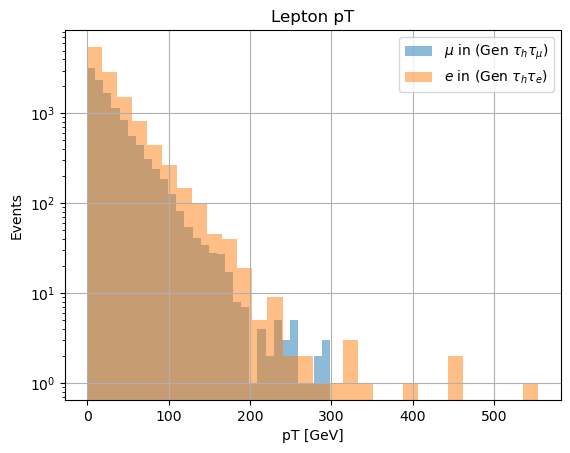

In [17]:
# plt.hist(gen_leptons[is_hh].pt, bins=100, alpha=0.5) # This means nothgin as there will be 
plt.hist(gen_leptons[is_hm].pt, bins=30, alpha=0.5, label=r"$\mu$ in (Gen $\tau_h\tau_\mu$)")     
plt.hist(gen_leptons[is_he].pt, bins=30, alpha=0.5, label=r"$e$ in (Gen $\tau_h\tau_e$)")     

plt.xlabel("pT [GeV]")
plt.ylabel("Events")
plt.legend()
plt.title("Lepton pT") 
plt.grid(True)
plt.yscale("log")

plt.show()


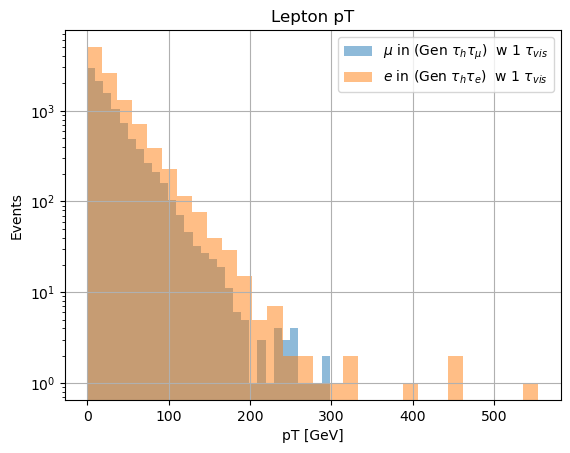

In [18]:
plt.hist(gen_leptons[hm_with_1_visTau].pt, bins=30, alpha=0.5, label=r"$\mu$ in (Gen $\tau_h\tau_\mu$)  w 1 $\tau_{vis}$")   
plt.hist(gen_leptons[he_with_1_visTau].pt, bins=30, alpha=0.5, label=r"$e$ in (Gen $\tau_h\tau_e$)  w 1 $\tau_{vis}$")   

plt.xlabel("pT [GeV]")
plt.ylabel("Events")
plt.legend()
plt.title("Lepton pT") 
plt.grid(True)
plt.yscale("log")

plt.show()


In [19]:
def separate_tau_decay_products(gen_taus, gen_leptons, dr_lep_thres = 0.1):
    """
    Separates signal Taus into 'Leptonic' and 'Hadronic' based on 
    DeltaR matching with the signal leptons.
    """
    # Cartesian pairs: (Events, N_Taus, N_Leptons)
    pairs = ak.cartesian([gen_taus, gen_leptons], nested=True)
    tau, lep = ak.unzip(pairs)
    
    # Find closest Lepton to each Tau
    dr_vals = tau.deltaR(lep)
    
    # If a Tau has a lepton within dR < dr_lep_thres = 0.1, it's leptonic
    has_lepton_match = ak.any(dr_vals < dr_lep_thres, axis=-1)
    
    tau_lep = gen_taus[has_lepton_match]
    tau_had = gen_taus[~has_lepton_match]
        
    return tau_lep, tau_had

In [20]:
def match_objects(left_collection, right_collection, dr_max=0.4):
    """
    Matches 'left' (Reco) to 'right' (Gen). 
    Returns the INDICES of 'right' that match 'left'.
    
    Args:
        left_collection:  Array of shape (Events, N_Left)  (e.g., Jets)
        right_collection: Array of shape (Events, N_Right) (e.g., GenParts)
        dr_max: Float threshold (default 0.4)

    Returns:
        final_indices: Array of shape (Events, N_Left)
        valid_match: Boolean array of shape (Events, N_Left)
                     True if the object in 'left' overlaps with anything in 'right'.
    """
    # Cartesian Pairs
    pairs = ak.cartesian([left_collection, right_collection], nested=True)
    left, right = ak.unzip(pairs)
    
    # Minimization: Find closest match
    dr = left.deltaR(right)
    best_idx = ak.argmin(dr, axis=-1, keepdims=True)
    best_dr = dr[best_idx]
    
    # Thresholding
    # Flatten to remove the extra axis from keepdims
    best_idx = ak.flatten(best_idx, axis=-1)
    best_dr = ak.flatten(best_dr, axis=-1)
    
    # Mask out bad matches (replace index with None)
    valid_match = best_dr < dr_max
    final_indices = ak.mask(best_idx, valid_match)
    
    return final_indices, valid_match

In [21]:
print("Decay Channel: hm")
# Filter objects to HM channel
gen_taus_hm = gen_taus[is_hm]
gen_leptons_hm = gen_leptons[is_hm]
ak8_hm = ak8_jets[is_hm]
ak4_hm = ak4_jets[is_hm]

# Separate Taus into Leptonic vs Hadronic
# What DeltaR should be chosen?
print("Separating Taus into Leptonic vs Hadronic, by DeltaR")
gen_tau_lep, gen_tau_had = separate_tau_decay_products(gen_taus_hm, gen_leptons_hm, dr_lep_thres=0.5)
print(f"Events with leptonic tau: {ak.sum(ak.any(gen_tau_lep, axis=1))}")
print(f"Events with hadronic tau: {ak.sum(ak.any(gen_tau_had, axis=1))}")

# --- Matching ---
print("\n--- Matching Objects to Gen Tau_h ---")

# Match AK8
idx_ak8, mask_ak8 = match_objects(ak8_hm, gen_tau_had, dr_max=0.8)
matched_ak8 = ak8_hm[mask_ak8] # Apply mask to get objects

# Match AK4
idx_ak4, mask_ak4 = match_objects(ak4_hm, gen_tau_had, dr_max=0.4)
matched_ak4 = ak4_hm[mask_ak4]

print(f"Events with matched AK8: {ak.sum(ak.any(mask_ak8, axis=1))}")
print(f"Events with matched AK4: {ak.sum(ak.any(mask_ak4, axis=1))}")

Decay Channel: hm
Separating Taus into Leptonic vs Hadronic, by DeltaR
Events with leptonic tau: 79758
Events with hadronic tau: 79982

--- Matching Objects to Gen Tau_h ---
Events with matched AK8: 693
Events with matched AK4: 10484


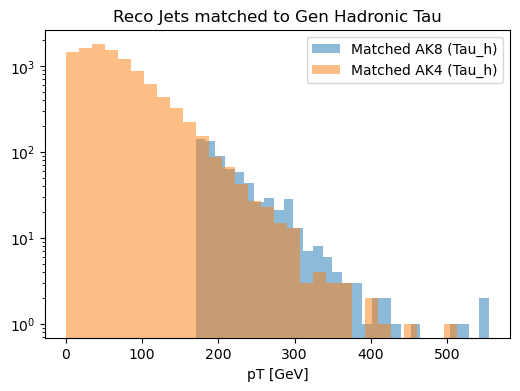

In [32]:
# InteractiveShell.ast_node_interactivity = "last"
plt.figure(figsize=(6,4))
plt.hist(ak.flatten(matched_ak8.pt), bins=30, alpha=0.5, label='Matched AK8 (Tau_h)')
plt.hist(ak.flatten(matched_ak4.pt), bins=30, alpha=0.5, label='Matched AK4 (Tau_h)')
plt.xlabel("pT [GeV]")
plt.legend()
plt.title("Reco Jets matched to Gen Hadronic Tau")
plt.yscale("log")

plt.show()

Channel | Events   | Matched AK4  | Matched AK8 
--------------------------------------------------
HH    | 51872    | 93705        | 5601        
HM    | 11445    | 10587        | 707         
HE    | 11771    | 10911        | 773         


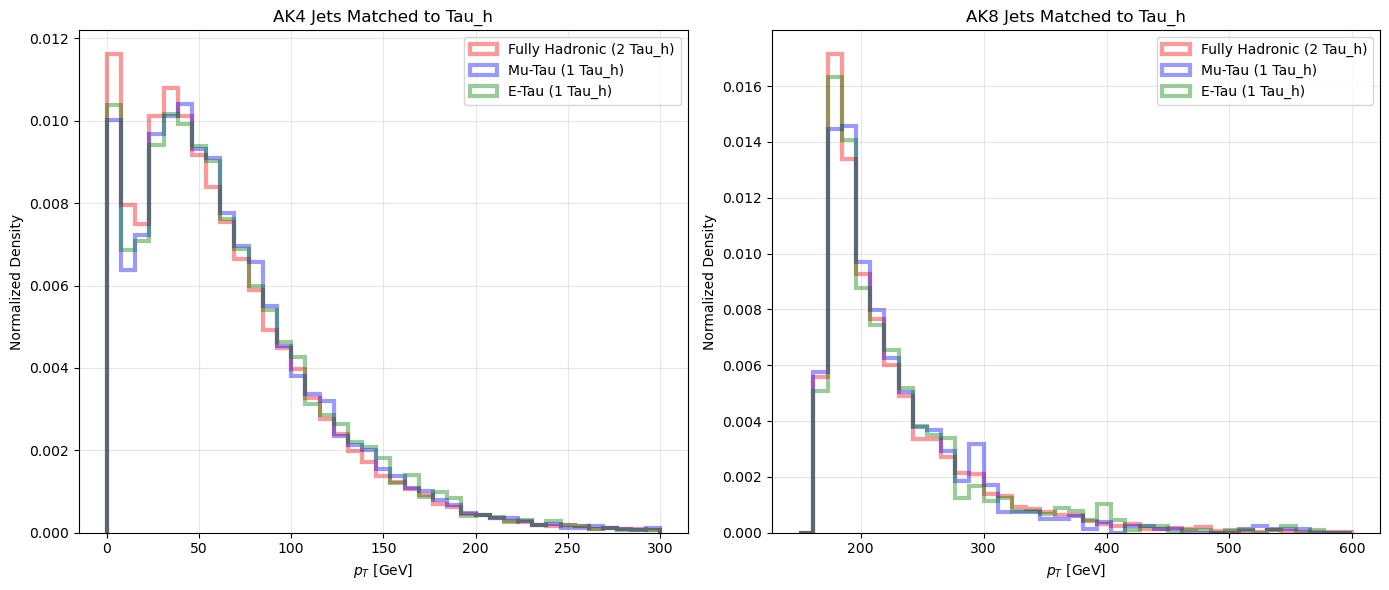

In [33]:
channels = {
    "HH": {"mask": is_hh, "color": "red",  "label": "Fully Hadronic (2 Tau_h)"},
    "HM": {"mask": is_hm, "color": "blue", "label": "Mu-Tau (1 Tau_h)"},
    "HE": {"mask": is_he, "color": "green","label": "E-Tau (1 Tau_h)"}
}

# Dictionaries to store results for plotting later
results_ak4 = {}
results_ak8 = {}

print(f"{'Channel':<5} | {'Events':<8} | {'Matched AK4':<12} | {'Matched AK8':<12}")
print("-" * 50)

for name, info in channels.items():
    mask = info['mask']
    
    # Filter Collections by Event Mask
    if ak.sum(mask) == 0:
        print(f"{name:<5} | 0        | Skipped")
        continue
        
    _gen_taus    = gen_taus[mask]
    _gen_leptons = gen_leptons[mask]
    _ak4         = ak4_jets[mask]
    _ak8         = ak8_jets[mask]
    
    # Separate Leptonic vs Hadronic Taus
    # Note: For HH, _gen_leptons is empty, so ALL taus become 'hadronic' (Correct!)
    _tau_lep, _tau_had = separate_tau_decay_products(
        _gen_taus, 
        _gen_leptons, 
        dr_lep_thres=0.4
    )
    
    # Match AK4 to Gen Hadronic Tau
    idx_ak4, mask_ak4 = match_objects(_ak4, _tau_had, dr_max=0.4)
    matched_ak4_obj   = _ak4[mask_ak4]
    
    # Match AK8 to Gen Hadronic Tau
    idx_ak8, mask_ak8 = match_objects(_ak8, _tau_had, dr_max=0.8)
    matched_ak8_obj   = _ak8[mask_ak8]
    
    # Store flattened pT for plotting
    results_ak4[name] = ak.flatten(matched_ak4_obj.pt)
    results_ak8[name] = ak.flatten(matched_ak8_obj.pt)
    
    # Print stats
    n_ev = ak.sum(mask)
    n_m4 = ak.count(results_ak4[name])
    n_m8 = ak.count(results_ak8[name])
    print(f"{name:<5} | {n_ev:<8} | {n_m4:<12} | {n_m8:<12}")


fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot AK4 Matches
for name, data in results_ak4.items():
    ax[0].hist(
        data, 
        bins=np.linspace(0, 300, 40), 
        alpha=0.4, 
        label=f"{channels[name]['label']}", 
        color=channels[name]['color'],
        density=True, # Normalized to compare shape (since HH has 2x taus)
        histtype='step',
        lw = 3
    )

ax[0].set_title("AK4 Jets Matched to Tau_h")
ax[0].set_xlabel("$p_T$ [GeV]")
ax[0].set_ylabel("Normalized Density")
ax[0].legend()
ax[0].grid(alpha=0.3)

# Plot AK8 Matches
for name, data in results_ak8.items():
    ax[1].hist(
        data, 
        bins=np.linspace(150, 600, 40), # Higher range for boosted
        alpha=0.4, 
        label=f"{channels[name]['label']}", 
        color=channels[name]['color'],
        density=True,
        histtype='step',
        lw = 3
    )

ax[1].set_title("AK8 Jets Matched to Tau_h")
ax[1].set_xlabel("$p_T$ [GeV]")
ax[1].set_ylabel("Normalized Density")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Looking at the Reco now

In [34]:
electrons = build_collection(events, "Electron", behavior="Momentum4D")
muons = build_collection(events, "Muon", behavior="Momentum4D")
taus = build_collection(events, "Tau", behavior="Momentum4D")

In [35]:
electrons.fields

['seediEtaOriX',
 'convVeto',
 'cutBased',
 'cutBased_HEEP',
 'isPFcand',
 'jetNDauCharged',
 'lostHits',
 'mvaIso_WP80',
 'mvaIso_WP90',
 'mvaNoIso_WP80',
 'mvaNoIso_WP90',
 'seedGain',
 'tightCharge',
 'jetIdx',
 'photonIdx',
 'svIdx',
 'fsrPhotonIdx',
 'charge',
 'pdgId',
 'seediPhiOriY',
 'vidNestedWPBitmap',
 'vidNestedWPBitmapHEEP',
 'deltaEtaSC',
 'dr03EcalRecHitSumEt',
 'dr03HcalDepth1TowerSumEt',
 'dr03TkSumPt',
 'dr03TkSumPtHEEP',
 'dxy',
 'dxyErr',
 'dz',
 'dzErr',
 'eInvMinusPInv',
 'energyErr',
 'eta',
 'hoe',
 'ip3d',
 'jetPtRelv2',
 'jetRelIso',
 'mass',
 'miniPFRelIso_all',
 'miniPFRelIso_chg',
 'mvaHZZIso',
 'mvaIso',
 'mvaNoIso',
 'pfRelIso03_all',
 'pfRelIso03_chg',
 'phi',
 'pt',
 'r9',
 'scEtOverPt',
 'sieie',
 'sip3d',
 'mvaTTH',
 'genPartFlav',
 'genPartIdx']

In [36]:
def old_electronSel(leptons: ak.Array) -> ak.Array:
    lsel = (
        leptons.mvaIso_WP90
        & (leptons.pt > 20)
        & (abs(leptons.eta) < 2.5)
        & (abs(leptons.dz) < 0.2)
        & (abs(leptons.dxy) < 0.045)
    )
    return lsel

def old_muonSel(leptons: ak.Array) -> ak.Array:
    lsel = (
        leptons.tightId
        & (leptons.pt > 20)
        & (abs(leptons.eta) < 2.4)
        & (abs(leptons.dz) < 0.2)
        & (abs(leptons.dxy) < 0.045)
    )
    return lsel

In [37]:
is_sel_electrons = old_electronSel(electrons)
is_sel_muons = old_muonSel(muons)

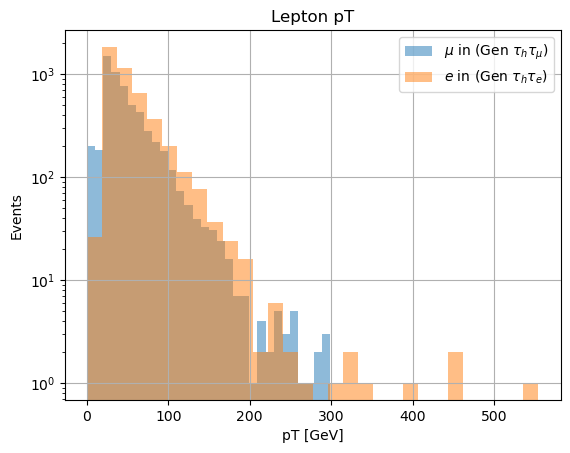

In [38]:
mask_m = (is_hm & 
        (ak.sum(is_sel_muons, axis=1) != 0) &      # Has Reco Muon
        (ak.sum(is_sel_electrons, axis=1) == 0)    # No Reco Electrons
        )

mask_e = (is_he & 
        (ak.sum(is_sel_electrons, axis=1) != 0) &  # Has Reco Electron
        (ak.sum(is_sel_muons, axis=1) == 0)        # No Reco Muons
        )

plt.hist(gen_leptons[mask_m].pt, bins=30, alpha=0.5, label=r"$\mu$ in (Gen $\tau_h\tau_\mu$)")     
plt.hist(gen_leptons[mask_e].pt, bins=30, alpha=0.5, label=r"$e$ in (Gen $\tau_h\tau_e$)")     

plt.xlabel("pT [GeV]")
plt.ylabel("Events")
plt.legend()
plt.title("Lepton pT") 
plt.grid(True)
plt.yscale("log")

plt.show()


In [39]:
mask_m = (is_hm & 
        (ak.sum(is_sel_muons, axis=1) != 0) &      # Has Reco Muon
        (ak.sum(is_sel_electrons, axis=1) == 0)    # No Reco Electrons
        )

mask_e = (is_he & 
        (ak.sum(is_sel_electrons, axis=1) != 0) &  # Has Reco Electron
        (ak.sum(is_sel_muons, axis=1) == 0)        # No Reco Muons
        )


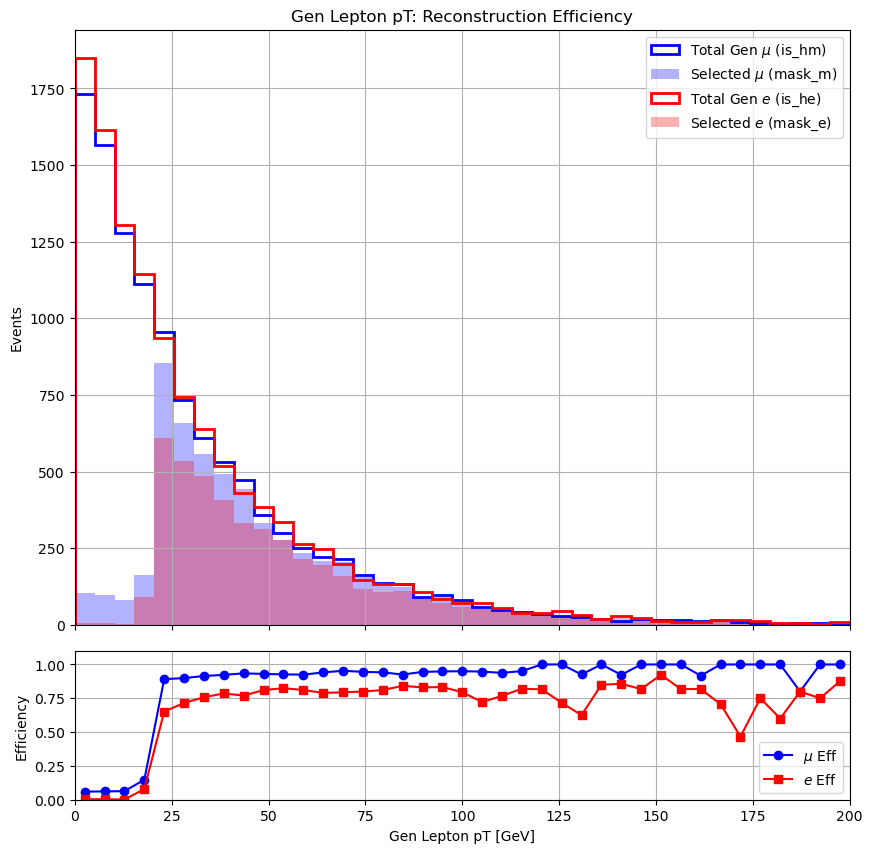

In [40]:
# Plot
fig, (ax, rax) = plt.subplots(
    2, 1, 
    figsize=(10, 10), 
    gridspec_kw={"height_ratios": [4, 1], "hspace": 0.07}, 
    sharex=True
)

bins = np.linspace(0, 200, 40) 
centers = (bins[:-1] + bins[1:]) / 2

# --- Muon Channel ---
# Denominator
ax.hist(ak.flatten(gen_leptons[is_hm].pt), bins=bins, 
        label=r"Total Gen $\mu$ (is_hm)", histtype='step', color='blue', lw=2)

# Numerator
ax.hist(ak.flatten(gen_leptons[mask_m].pt), bins=bins, 
        label=r"Selected $\mu$ (mask_m)", color='blue', alpha=0.3)

# --- Electron Channel ---
# Denominator
ax.hist(ak.flatten(gen_leptons[is_he].pt), bins=bins, 
        label=r"Total Gen $e$ (is_he)", histtype='step', color='red', lw=2)

# Numerator
ax.hist(ak.flatten(gen_leptons[mask_e].pt), bins=bins, 
        label=r"Selected $e$ (mask_e)", color='red', alpha=0.3)

# Top Panel Styling
ax.set_ylabel("Events")
ax.set_title("Gen Lepton pT: Reconstruction Efficiency")
ax.legend()
ax.grid(True)
# ax.set_yscale("log")
ax.set_xlim(bins[0], bins[-1])

def get_efficiency(num_array, den_array, bins):
    num_hist, _ = np.histogram(ak.flatten(num_array), bins=bins)
    den_hist, _ = np.histogram(ak.flatten(den_array), bins=bins)
    # Safe division
    eff = np.divide(num_hist, den_hist, out=np.zeros_like(num_hist, dtype=float), where=den_hist!=0)
    return eff

# Calculate
eff_mu = get_efficiency(gen_leptons[mask_m].pt, gen_leptons[is_hm].pt, bins)
eff_el = get_efficiency(gen_leptons[mask_e].pt, gen_leptons[is_he].pt, bins)

# Plot
rax.plot(centers, eff_mu, marker='o', linestyle='-', label=r"$\mu$ Eff", color='blue')
rax.plot(centers, eff_el, marker='s', linestyle='-', label=r"$e$ Eff", color='red')

# Bottom Panel Styling
rax.set_xlabel("Gen Lepton pT [GeV]")
rax.set_ylabel("Efficiency")
rax.set_ylim(0, 1.1)
rax.grid(True)
rax.legend() 
plt.show()

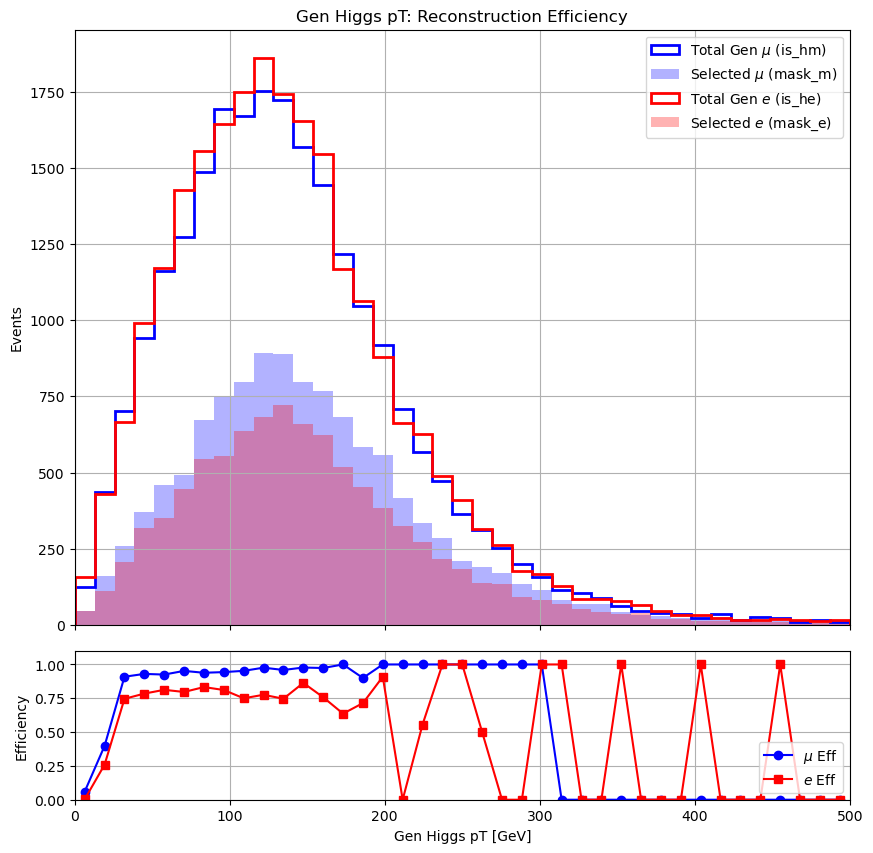

In [42]:
# Plot
fig, (ax, rax) = plt.subplots(
    2, 1, 
    figsize=(10, 10), 
    gridspec_kw={"height_ratios": [4, 1], "hspace": 0.07}, 
    sharex=True
)

bins = np.linspace(0, 500, 40) 
centers = (bins[:-1] + bins[1:]) / 2

# --- Muon Channel ---
# Denominator
ax.hist(ak.flatten(gen_h[is_hm].pt), bins=bins, 
        label=r"Total Gen $\mu$ (is_hm)", histtype='step', color='blue', lw=2)

# Numerator
ax.hist(ak.flatten(gen_h[mask_m].pt), bins=bins, 
        label=r"Selected $\mu$ (mask_m)", color='blue', alpha=0.3)

# --- Electron Channel ---
# Denominator
ax.hist(ak.flatten(gen_h[is_he].pt), bins=bins, 
        label=r"Total Gen $e$ (is_he)", histtype='step', color='red', lw=2)

# Numerator
ax.hist(ak.flatten(gen_h[mask_e].pt), bins=bins, 
        label=r"Selected $e$ (mask_e)", color='red', alpha=0.3)

# Top Panel Styling
ax.set_ylabel("Events")
ax.set_title("Gen Higgs pT: Reconstruction Efficiency")
ax.legend()
ax.grid(True)
# ax.set_yscale("log")
ax.set_xlim(bins[0], bins[-1])

def get_efficiency(num_array, den_array, bins):
    num_hist, _ = np.histogram(ak.flatten(num_array), bins=bins)
    den_hist, _ = np.histogram(ak.flatten(den_array), bins=bins)
    # Safe division
    eff = np.divide(num_hist, den_hist, out=np.zeros_like(num_hist, dtype=float), where=den_hist!=0)
    return eff

# Calculate
eff_mu = get_efficiency(gen_leptons[mask_m].pt, gen_leptons[is_hm].pt, bins)
eff_el = get_efficiency(gen_leptons[mask_e].pt, gen_leptons[is_he].pt, bins)

# Plot
rax.plot(centers, eff_mu, marker='o', linestyle='-', label=r"$\mu$ Eff", color='blue')
rax.plot(centers, eff_el, marker='s', linestyle='-', label=r"$e$ Eff", color='red')

# Bottom Panel Styling
rax.set_xlabel("Gen Higgs pT [GeV]")
rax.set_ylabel("Efficiency")
rax.set_ylim(0, 1.1)
rax.grid(True)
rax.legend() 
plt.show()

In [ ]:
ak8_hm = ak8_jets[is_hm]
ak4_hm = ak4_jets[is_hm]
reco_muon_hm = muons[is_hm]
reco_tau_hm = taus[is_hm]

# MATCHING THE HADRONIC SIDE (Tau_h)

# AK8 jet matches the Gen Tau_h: (Boosted topology)
idx_ak8_tau, mask_ak8_tau = match_objects(ak8_hm, gen_tau_had, dr_max=0.8)
matched_ak8_jets = ak8_hm[mask_ak8_tau]

# AK4 jet matches the Gen Tau_h: (Resolved topology)
idx_ak4_tau, mask_ak4_tau = match_objects(ak4_hm, gen_tau_had, dr_max=0.4)
matched_ak4_jets = ak4_hm[mask_ak4_tau]

# Reco Tau matches the Gen Tau_h: (Calibration)
idx_reco_tau, mask_reco_tau = match_objects(reco_tau_hm, gen_tau_had, dr_max=0.3)
matched_reco_taus = reco_tau_hm[mask_reco_tau]